In [1]:
from SFstarred.DataStarred import DataStarred
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm, LogNorm, Normalize, TwoSlopeNorm
import numpy as np
from astropy.io import fits

/Users/felavila/miniconda3/envs/SFstarred/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import numpy as np
import os
import h5py

import lenstronomy.Util.kernel_util as kernel_util
import lenstronomy.Util.util as util
from astroObjectAnalyser.DataAnalysis.analysis import Analysis
from astroObjectAnalyser.astro_object_superclass import StrongLensSystem

import matplotlib.pyplot as plt
#import seaborn as sns

from mpl_toolkits.axes_grid1 import AxesGrid, make_axes_locatable
from astropy.io.fits import getheader

import lenstronomy.Util.mask_util as mask_util
from lenstronomy.Data.coord_transforms import Coordinates

%matplotlib inline

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
obj_name = "PSJ0147+4630"
path_data = f"../reduced_data/{obj_name}_F160W_drz_sci.fits"
path_wht = f"../reduced_data/{obj_name}_F160W_drz_wht.fits"
# path_weight = "/data/favila/data_2/HST_IMAGES_0214_2105/WG0214-2105_F160W_drz_wht.fits"
# Data setup for starred
#remove_star: 5 (light contamination from other source), 8 (it is one of the QSO images); 9 (large residuals) 
data = DataStarred(path_data,path_wht)


FileNotFoundError: File not found: ../reduced_data/PSJ0147+4630_F160W_drz_sci.fits

In [5]:
data.cut_out_lens(times_maxsep=1.9, plot=True, refine_centers=True, centroid_box_size=22, centroid_method="2dg",num_pix=80,detec_fwhm=3,threshold = 5
                  ,skycorr = np.array([0,0]))

NameError: name 'data' is not defined

The search for stars will be with detec_fwhm = 3.000 and threshold = 2.500
Querying Gaia catalog for stars in the field...
Gaia query returned 1 sources within 117.95900278341722 arcsec of the image center.
Found 34 Gaia sources with valid positions outside the object region.
Using 5 Gaia stars in the field.
Detected 34 stars outside the object region.


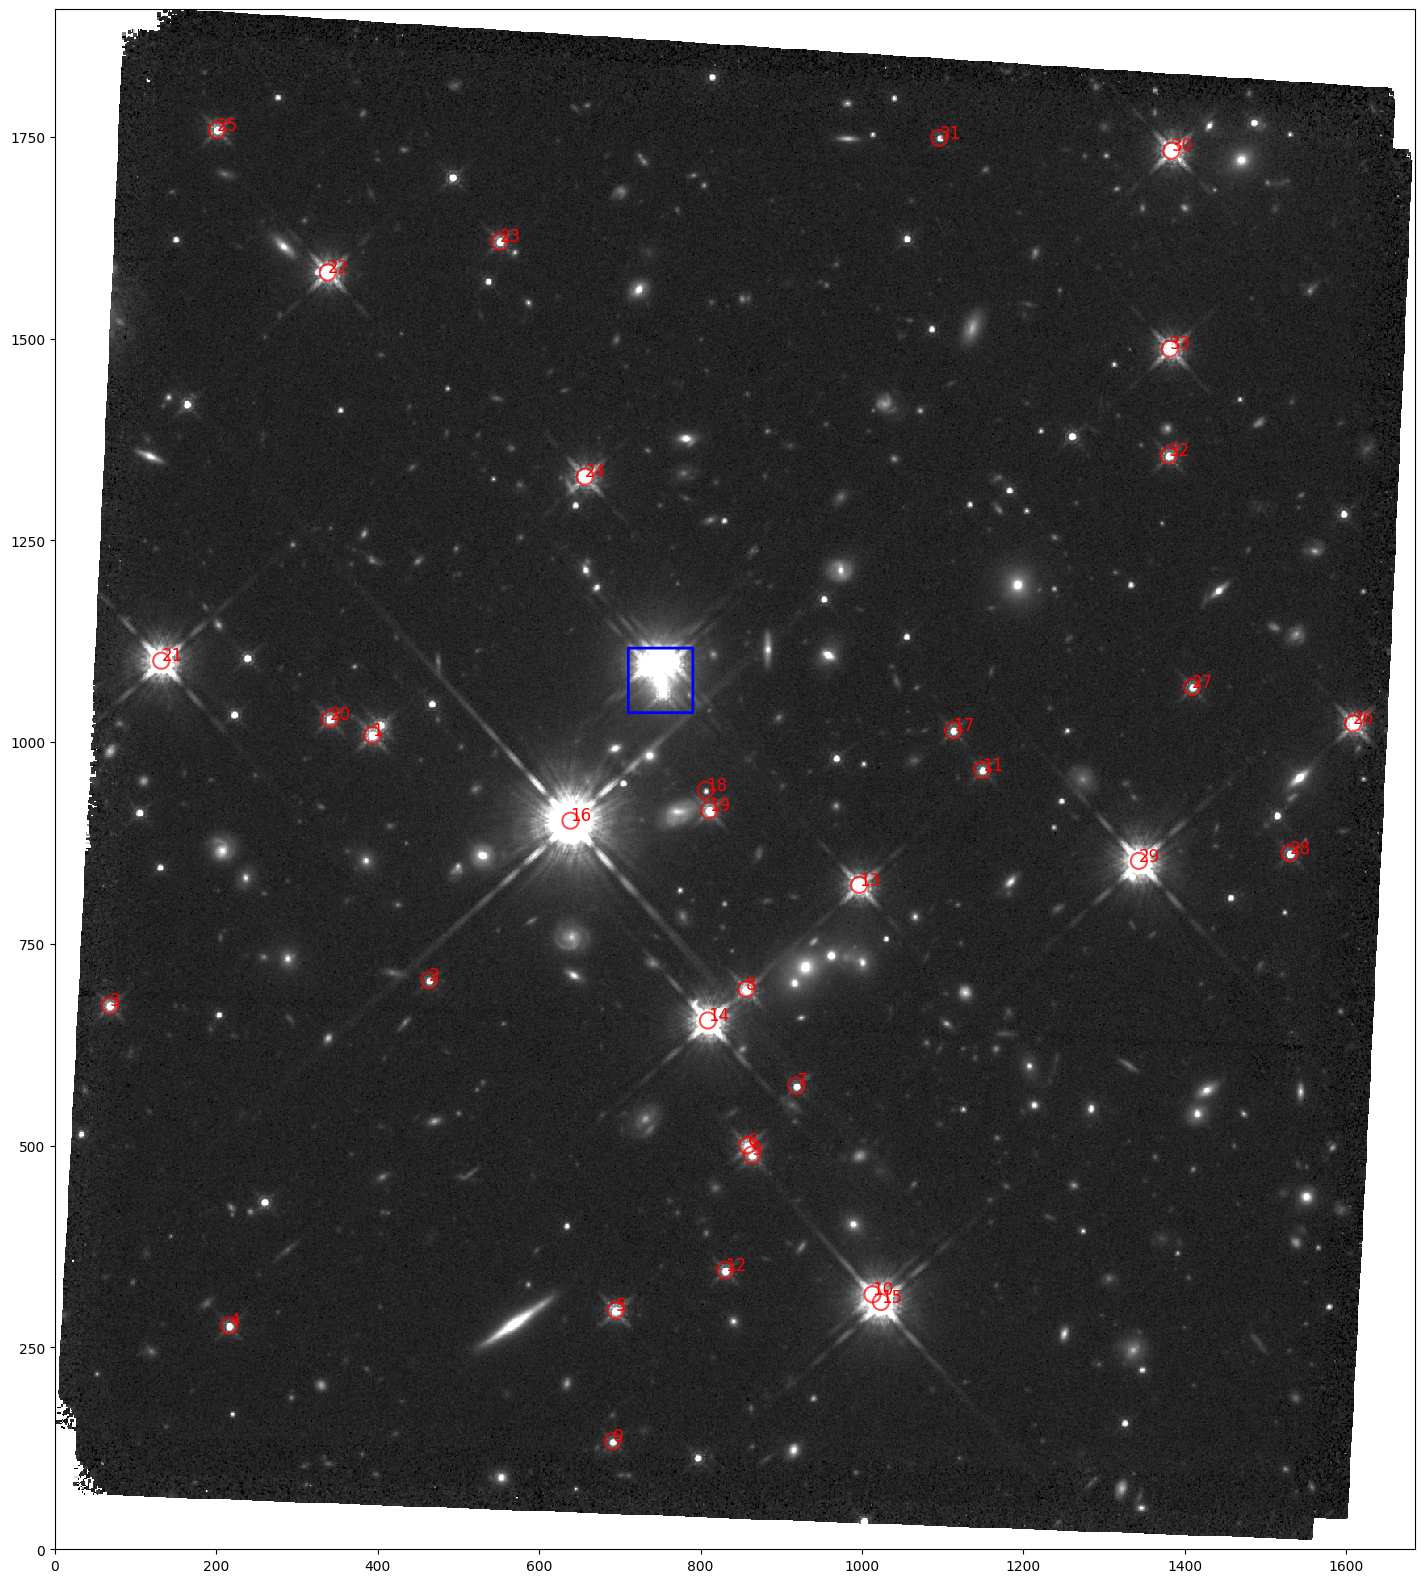


Calling make_cutouts with 34 sources and size 80 pix

Star ID 1: (x,y) = (692, 135)
The read in x, y are: 692.1688373872579 135.10409834197583
x_shift, y_shift = -0.16884 -0.1041
Before shift centroid = 40.0376 39.4568
After shift centroid =  40.019 39.4375
The subimage peak flux (x,y) = (40), 38)


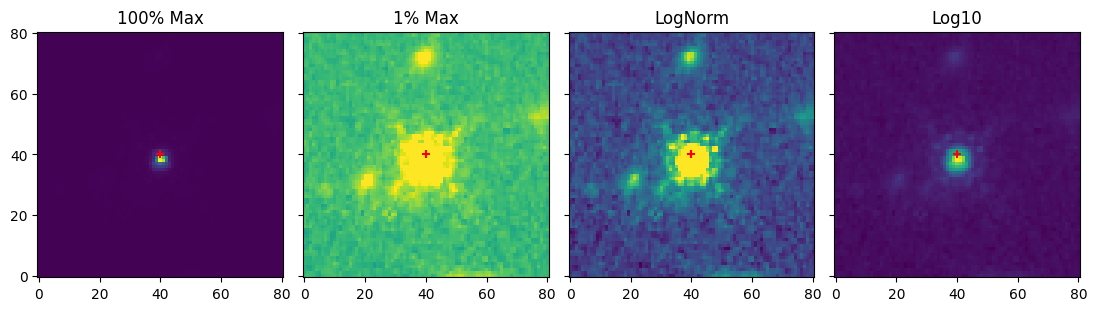

Star ID 2: (x,y) = (394, 1010)
The read in x, y are: 394.368738292509 1010.1324127541121
x_shift, y_shift = -0.36874 -0.13241
Before shift centroid = 40.1444 39.6003
After shift centroid =  40.1009 39.5851
The subimage peak flux (x,y) = (41), 38)


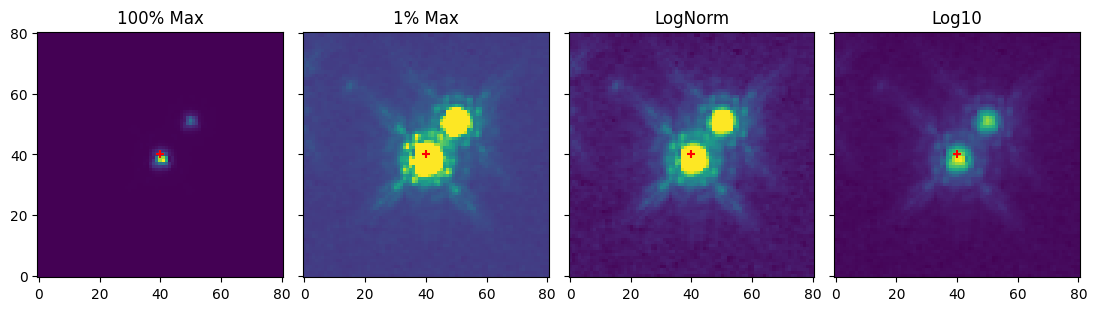

Star ID 3: (x,y) = (465, 706)
The read in x, y are: 464.80023775736566 706.0659565831531
x_shift, y_shift = 0.19976 -0.06596
Before shift centroid = 40.0554 39.6556
After shift centroid =  40.0703 39.6722
The subimage peak flux (x,y) = (41), 39)


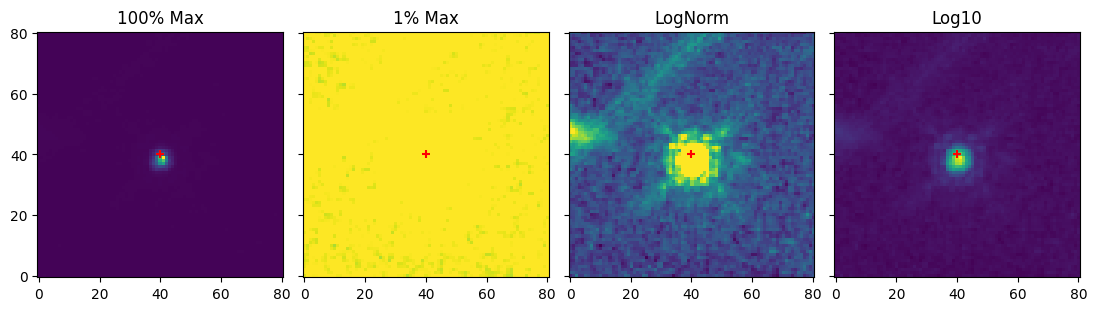

Star ID 4: (x,y) = (69, 675)
The read in x, y are: 69.01083691507017 674.9415683920273
x_shift, y_shift = -0.01084 0.05843
Before shift centroid = 40.1042 39.6454
After shift centroid =  nan nan
The subimage peak flux (x,y) = (0), 0)
This object does not have a central peak and will be excluded.

Star ID 5: (x,y) = (217, 278)
The read in x, y are: 217.10287602698247 278.21953788015776
x_shift, y_shift = -0.10288 -0.21954
Before shift centroid = 40.0818 39.5885
After shift centroid =  40.0672 39.5719
The subimage peak flux (x,y) = (41), 38)


/Users/felavila/Work/MyPackages/SFstarred/SFstarred/utils.py:241: RuntimeWarning: All-NaN slice encountered
  peak_flux = np.nanmax(subimage)


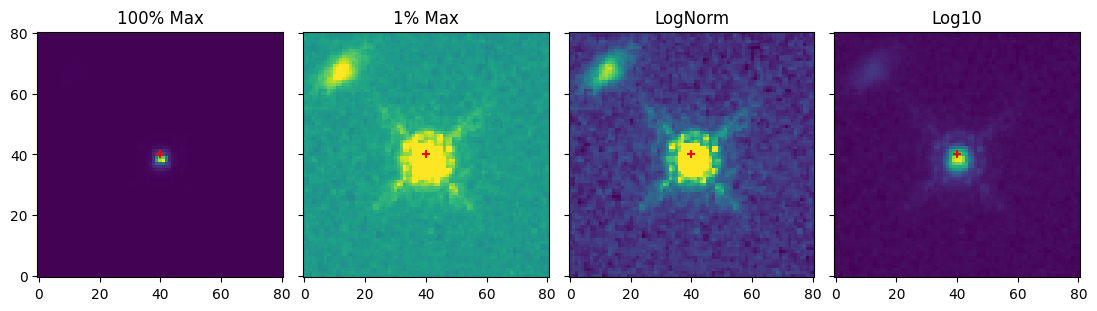

Star ID 6: (x,y) = (696, 297)
The read in x, y are: 695.8485584506333 297.3701515768839
x_shift, y_shift = 0.15144 -0.37015
Before shift centroid = 40.0876 39.7051
After shift centroid =  40.1067 39.5968
The subimage peak flux (x,y) = (40), 39)


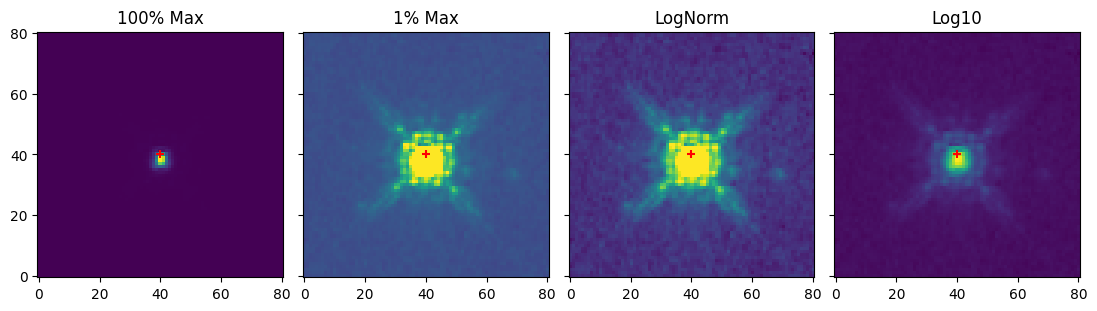

Star ID 7: (x,y) = (859, 501)
The read in x, y are: 859.0337546637124 501.4836319062003
x_shift, y_shift = -0.03375 -0.48363
Before shift centroid = 40.1142 39.6048
After shift centroid =  40.0754 39.5363
The subimage peak flux (x,y) = (40), 38)


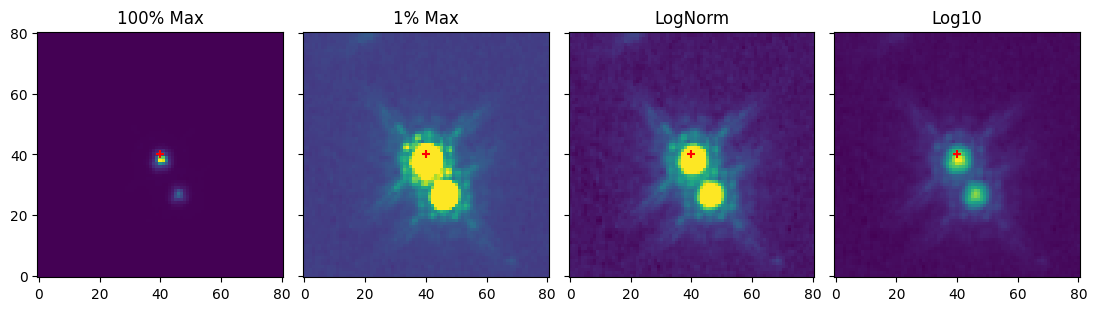

Star ID 8: (x,y) = (920, 575)
The read in x, y are: 919.652301406407 575.2635849953936
x_shift, y_shift = 0.3477 -0.26358
Before shift centroid = 40.0406 39.7246
After shift centroid =  40.0862 39.702
The subimage peak flux (x,y) = (41), 38)


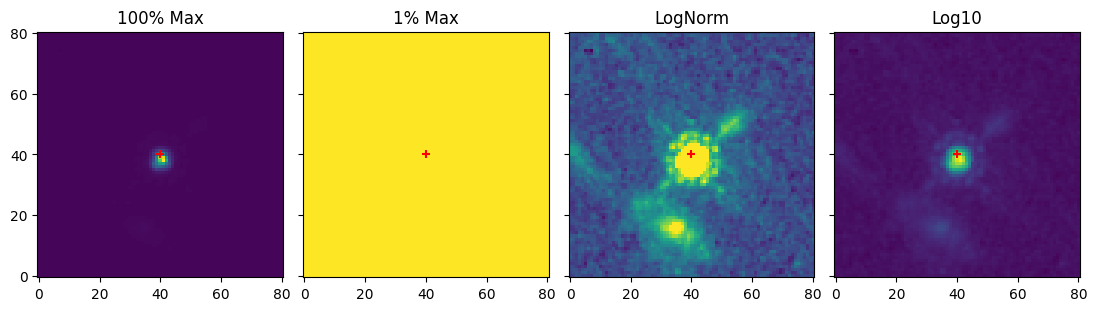

Star ID 9: (x,y) = (858, 695)
The read in x, y are: 857.7496635149943 695.272163084818
x_shift, y_shift = 0.25034 -0.27216
Before shift centroid = 40.0695 39.6549
After shift centroid =  40.1006 39.6394
The subimage peak flux (x,y) = (41), 38)


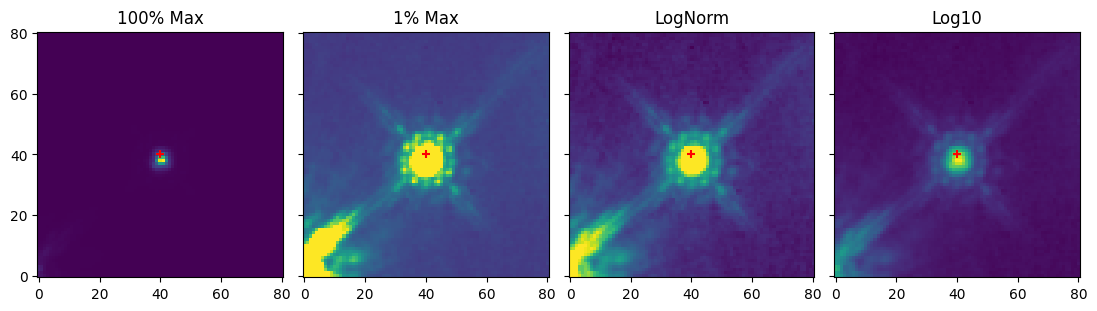

Star ID 10: (x,y) = (865, 490)
The read in x, y are: 864.686414003949 489.9538416449465
x_shift, y_shift = 0.31359 0.04616
Before shift centroid = 39.9983 39.6374
After shift centroid =  40.0481 39.6713
The subimage peak flux (x,y) = (35), 50)


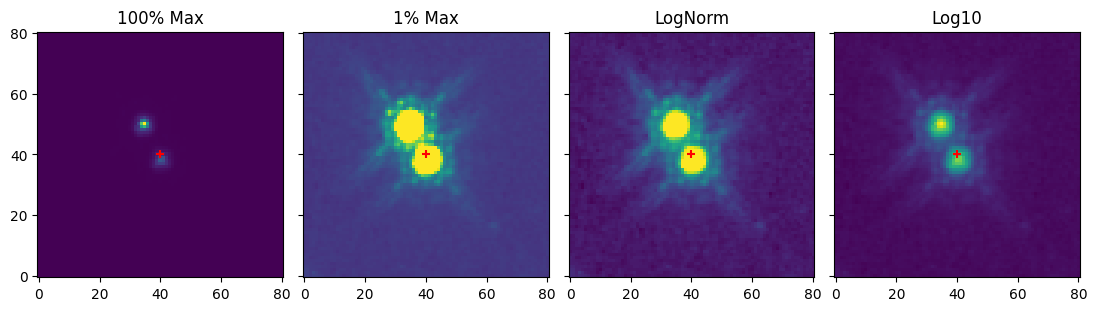

Star ID 11: (x,y) = (1014, 317)
The read in x, y are: 1014.0439447324075 316.8652195255345
x_shift, y_shift = -0.04394 0.13478
Before shift centroid = 40.0081 39.5225
After shift centroid =  39.9893 39.5565
The subimage peak flux (x,y) = (50), 29)


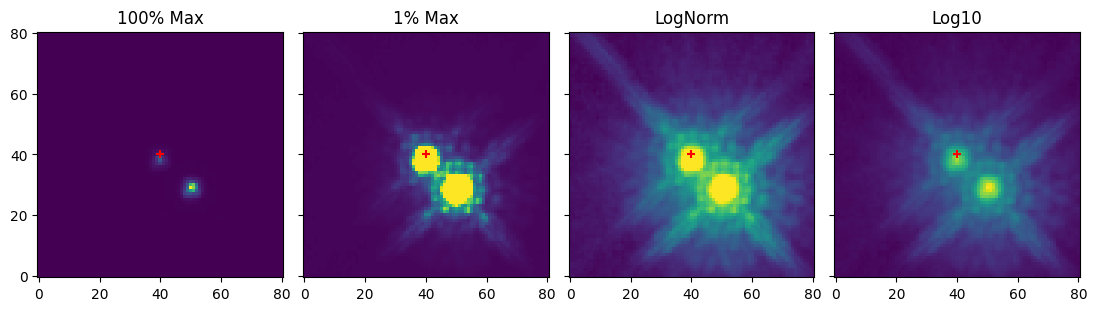

Star ID 12: (x,y) = (1150, 967)
The read in x, y are: 1149.928059246232 966.5902440287364
x_shift, y_shift = 0.07194 0.40976
Before shift centroid = 40.0406 39.6942
After shift centroid =  40.0932 39.69
The subimage peak flux (x,y) = (41), 38)


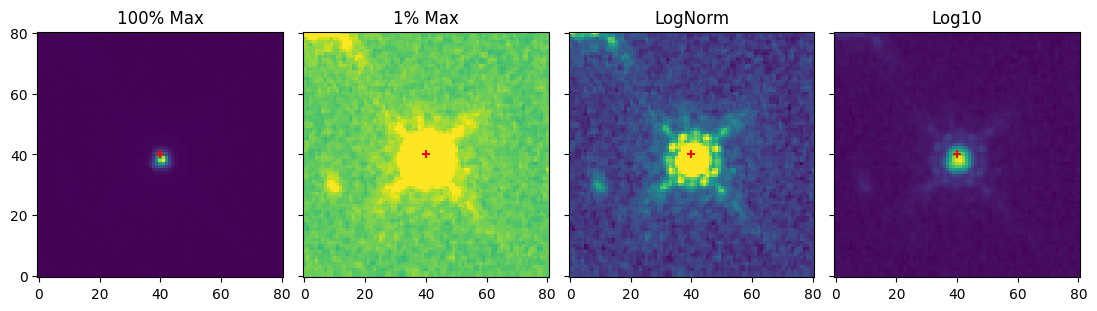

Star ID 13: (x,y) = (832, 347)
The read in x, y are: 831.6074500959229 346.909280677438
x_shift, y_shift = 0.39255 0.09072
Before shift centroid = 40.0133 39.5356
After shift centroid =  40.062 39.5463
The subimage peak flux (x,y) = (40), 38)


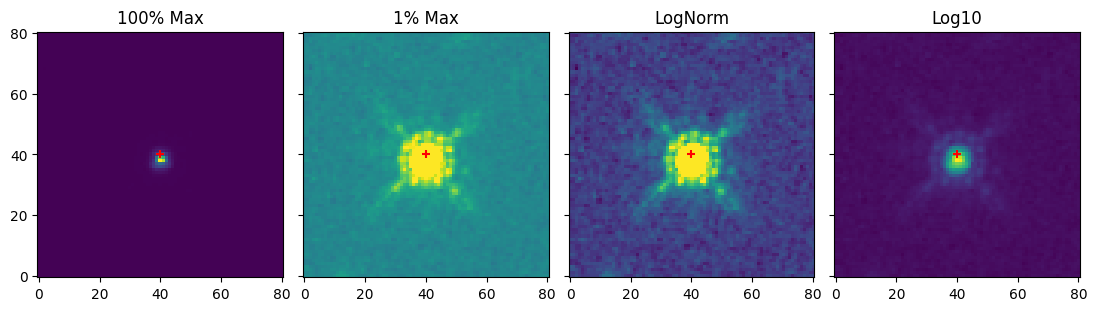

Star ID 14: (x,y) = (998, 824)
The read in x, y are: 997.5375289852273 824.2090015959811
x_shift, y_shift = 0.46247 -0.209
Before shift centroid = 40.0245 39.6082
After shift centroid =  40.0961 39.6104
The subimage peak flux (x,y) = (40), 38)


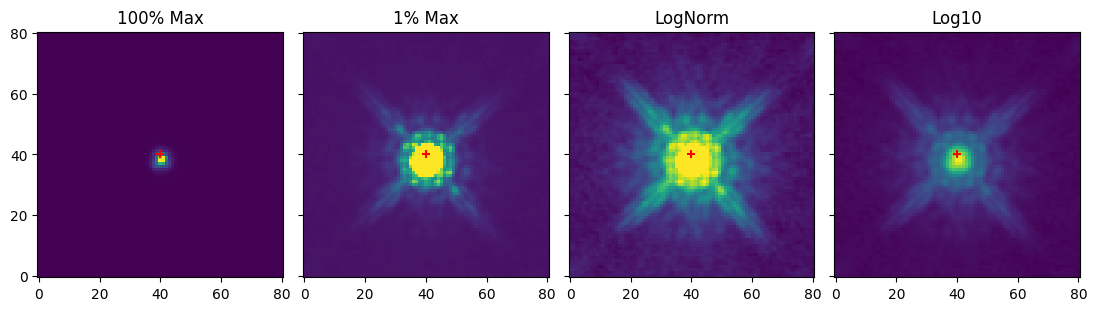

Star ID 15: (x,y) = (810, 656)
The read in x, y are: 810.1278665960984 656.173959382483
x_shift, y_shift = -0.12787 -0.17396
Before shift centroid = 40.0651 39.5535
After shift centroid =  40.0338 39.525
The subimage peak flux (x,y) = (40), 38)


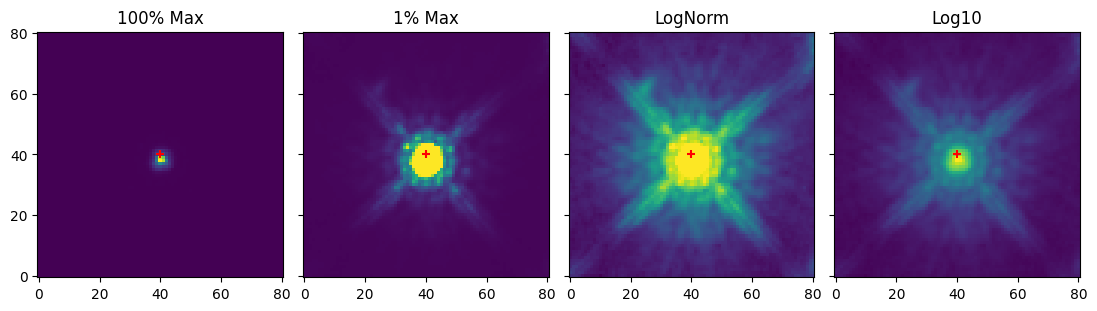

Star ID 16: (x,y) = (1024, 307)
The read in x, y are: 1024.4993860612817 307.4288444005225
x_shift, y_shift = -0.49939 -0.42884
Before shift centroid = 40.1767 39.7053
After shift centroid =  40.04 39.596
The subimage peak flux (x,y) = (40), 39)


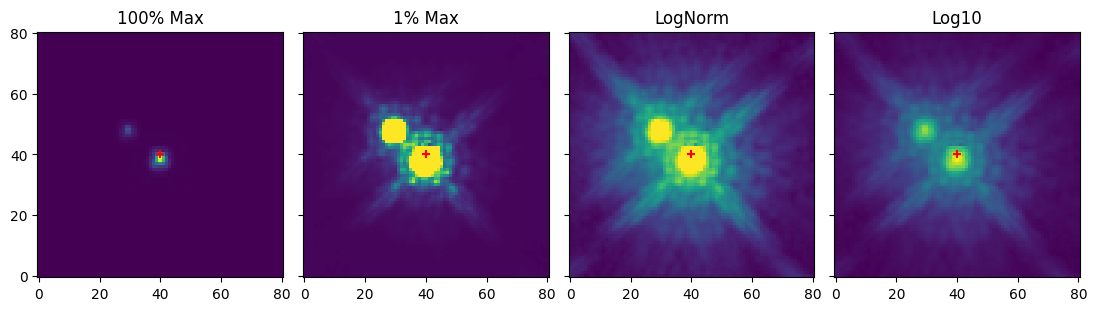

Star ID 17: (x,y) = (640, 904)
The read in x, y are: 639.8535112884163 903.7012803081604
x_shift, y_shift = 0.14649 0.29872
Before shift centroid = 39.9872 39.8981
After shift centroid =  39.9914 39.8825
The subimage peak flux (x,y) = (40), 38)


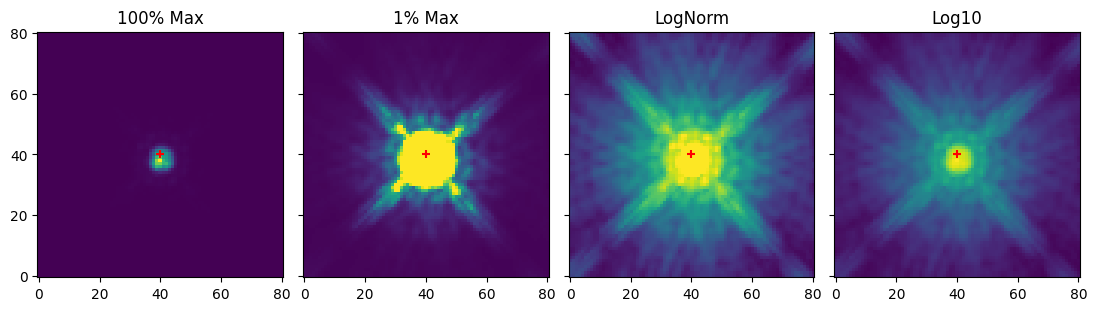

Star ID 18: (x,y) = (1114, 1016)
The read in x, y are: 1113.9397129829126 1015.793807675426
x_shift, y_shift = 0.06029 0.20619
Before shift centroid = 40.0678 39.5911
After shift centroid =  40.1115 39.6304
The subimage peak flux (x,y) = (41), 39)


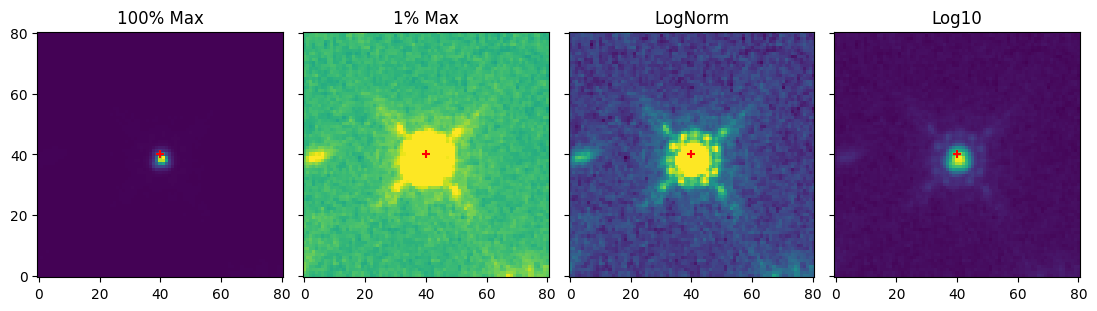

Star ID 19: (x,y) = (807, 942)
The read in x, y are: 807.3701442021478 941.7884544338642
x_shift, y_shift = -0.37014 0.21155
Before shift centroid = 40.0467 39.7497
After shift centroid =  40.0353 39.7003
The subimage peak flux (x,y) = (45), 13)


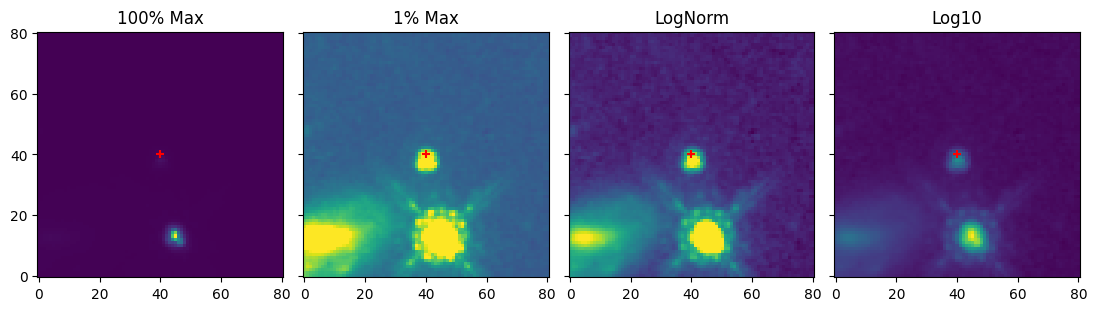

Star ID 20: (x,y) = (811, 917)
The read in x, y are: 811.492495394084 916.7385569912769
x_shift, y_shift = -0.4925 0.26144
Before shift centroid = 40.1511 39.7511
After shift centroid =  40.1028 39.6574
The subimage peak flux (x,y) = (41), 38)


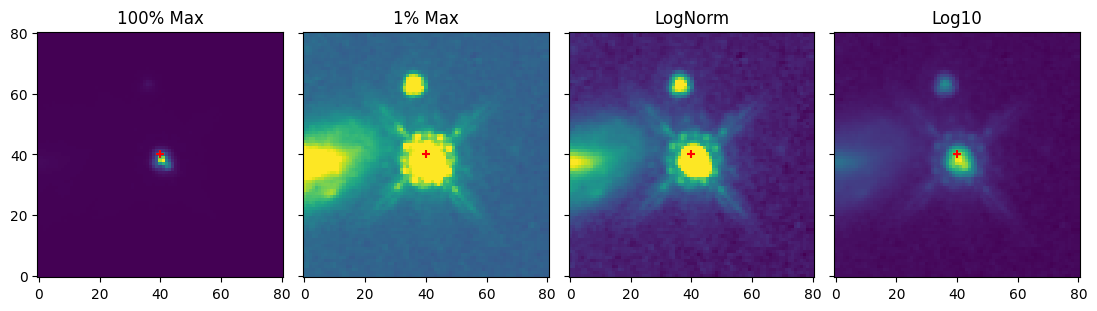

Star ID 21: (x,y) = (342, 1030)
The read in x, y are: 341.9117485910423 1029.955874575594
x_shift, y_shift = 0.08825 0.04413
Before shift centroid = 40.0683 39.5401
After shift centroid =  40.0882 39.5569
The subimage peak flux (x,y) = (40), 38)


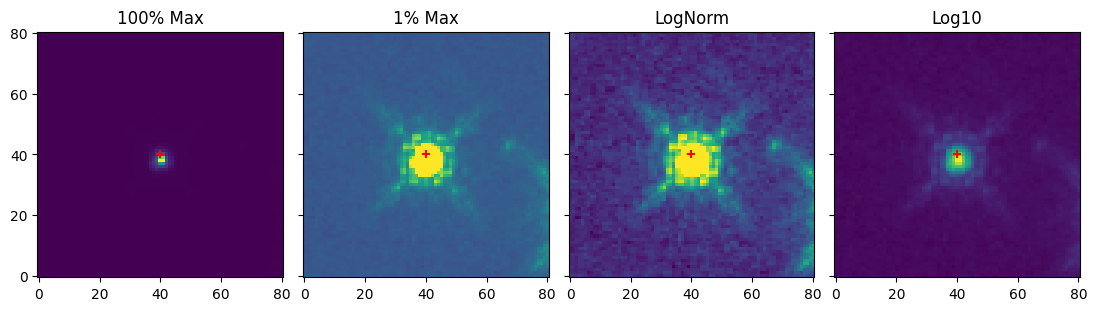

Star ID 22: (x,y) = (133, 1102)
The read in x, y are: 132.86711906773348 1101.8524903584293
x_shift, y_shift = 0.13288 0.14751
Before shift centroid = 40.0322 39.5593
After shift centroid =  40.07 39.5817
The subimage peak flux (x,y) = (41), 38)


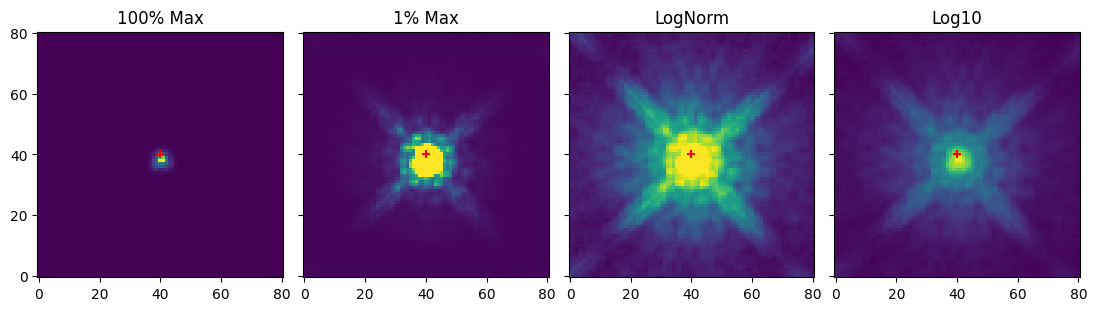

Star ID 23: (x,y) = (339, 1583)
The read in x, y are: 339.10001175677075 1582.97137945791
x_shift, y_shift = -0.10001 0.02862
Before shift centroid = 40.2064 39.8028
After shift centroid =  40.1848 39.7871
The subimage peak flux (x,y) = (41), 38)


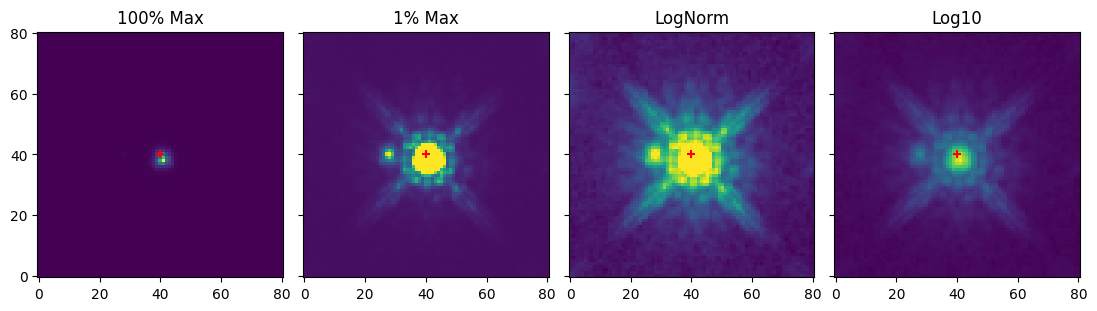

Star ID 24: (x,y) = (552, 1621)
The read in x, y are: 552.0747360879618 1621.2735430285366
x_shift, y_shift = -0.07474 -0.27354
Before shift centroid = 40.1814 39.7585
After shift centroid =  40.1399 39.7104
The subimage peak flux (x,y) = (41), 39)


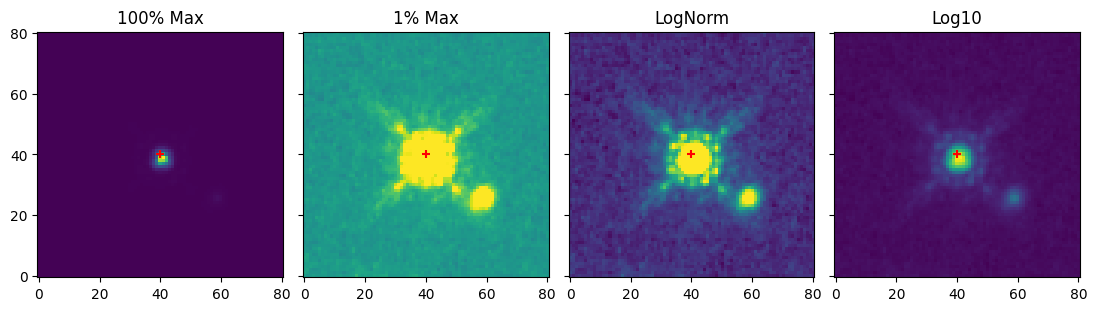

Star ID 25: (x,y) = (658, 1330)
The read in x, y are: 657.6903977726769 1330.034566509558
x_shift, y_shift = 0.3096 -0.03457
Before shift centroid = 40.08 39.6198
After shift centroid =  40.1125 39.6469
The subimage peak flux (x,y) = (41), 39)


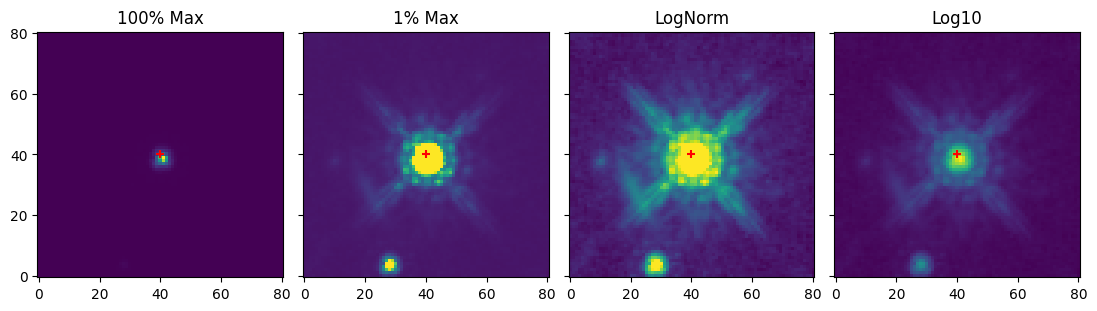

Star ID 26: (x,y) = (202, 1759)
The read in x, y are: 201.81270199650157 1759.4944133623071
x_shift, y_shift = 0.1873 -0.49441
Before shift centroid = 40.182 39.8501
After shift centroid =  40.1755 39.7558
The subimage peak flux (x,y) = (41), 39)


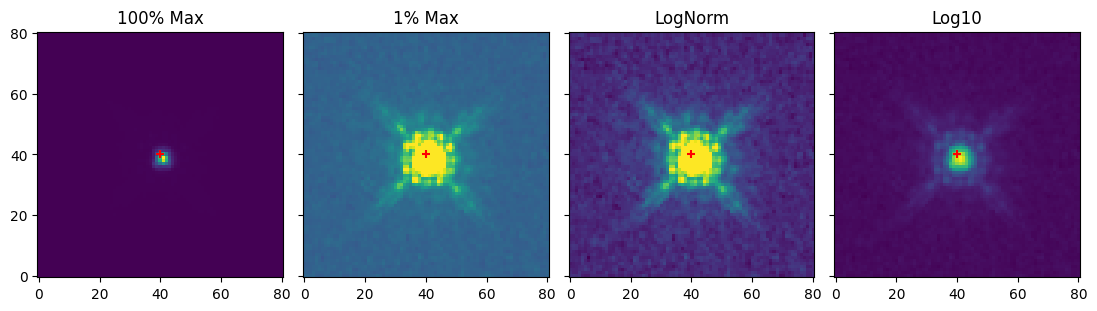

Star ID 27: (x,y) = (1609, 1024)
The read in x, y are: 1609.4504894092902 1024.2536984784213
x_shift, y_shift = -0.45049 -0.2537
Before shift centroid = 40.1323 39.657
After shift centroid =  40.0388 39.6026
The subimage peak flux (x,y) = (41), 38)


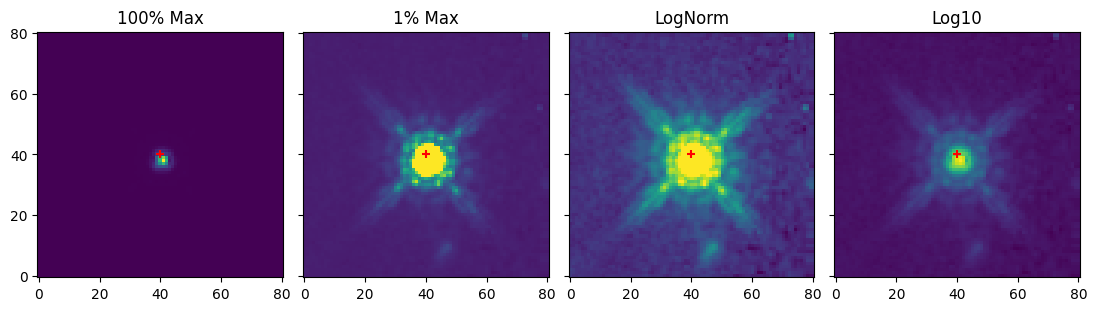

Star ID 28: (x,y) = (1410, 1069)
The read in x, y are: 1409.7761938965014 1069.329020618095
x_shift, y_shift = 0.22381 -0.32902
Before shift centroid = 40.125 39.674
After shift centroid =  40.1087 39.6744
The subimage peak flux (x,y) = (41), 38)


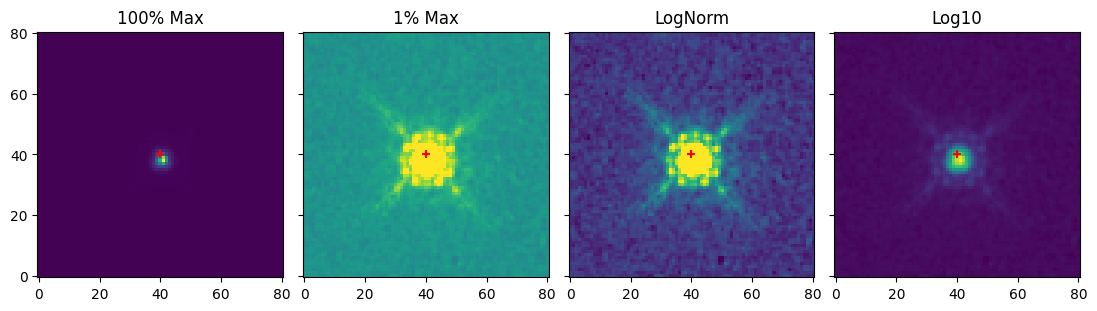

Star ID 29: (x,y) = (1531, 863)
The read in x, y are: 1530.941434806875 863.4556344774006
x_shift, y_shift = 0.05857 -0.45563
Before shift centroid = 40.116 39.7271
After shift centroid =  40.106 39.6644
The subimage peak flux (x,y) = (41), 38)


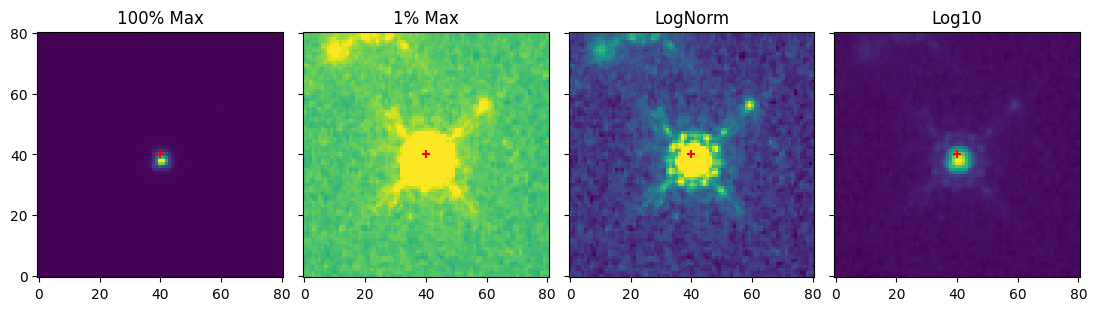

Star ID 30: (x,y) = (1344, 854)
The read in x, y are: 1344.1336686359143 853.9065061125273
x_shift, y_shift = -0.13367 0.09349
Before shift centroid = 40.0961 39.6047
After shift centroid =  40.0967 39.5945
The subimage peak flux (x,y) = (41), 38)


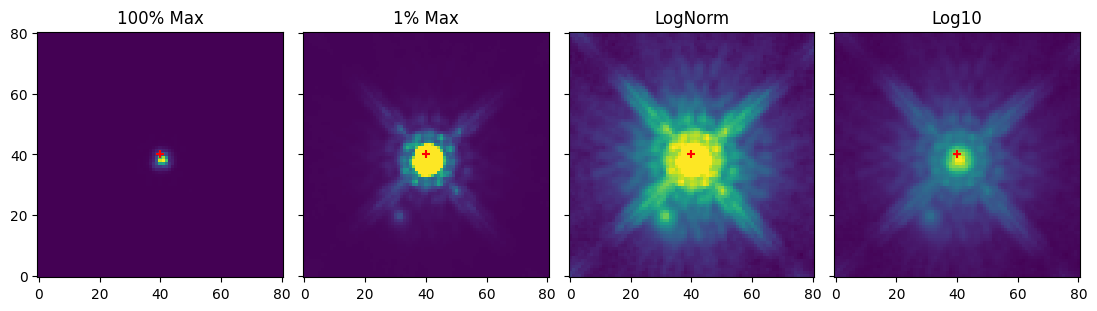

Star ID 31: (x,y) = (1384, 1734)
The read in x, y are: 1384.4355194291584 1733.7760043367769
x_shift, y_shift = -0.43552 0.224
Before shift centroid = 40.1683 39.8193
After shift centroid =  40.1048 39.7186
The subimage peak flux (x,y) = (41), 38)


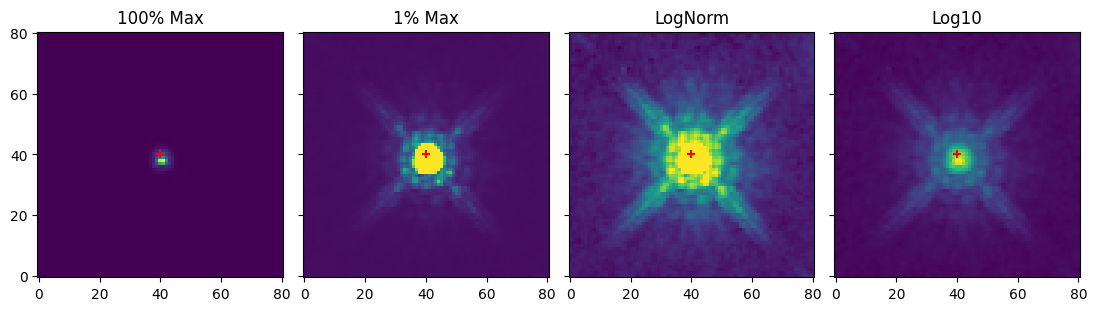

Star ID 32: (x,y) = (1097, 1750)
The read in x, y are: 1096.7749838167056 1749.63785685984
x_shift, y_shift = 0.22502 0.36214
Before shift centroid = 39.9936 39.4668
After shift centroid =  40.11 39.56
The subimage peak flux (x,y) = (40), 39)


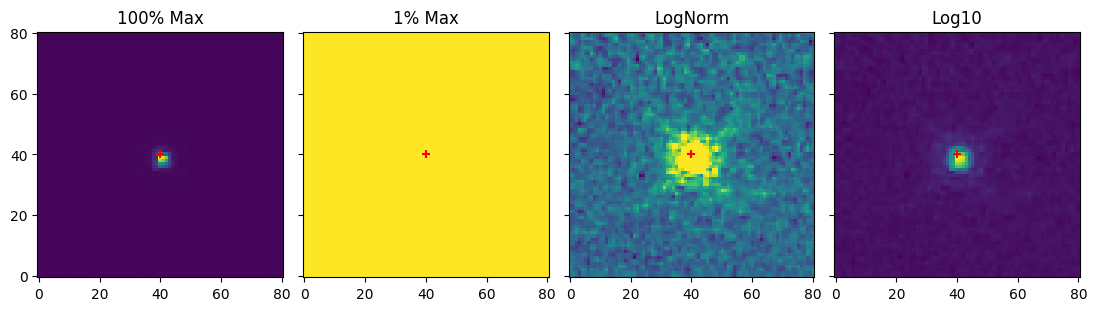

Star ID 33: (x,y) = (1381, 1356)
The read in x, y are: 1381.1178013653503 1356.0581198431128
x_shift, y_shift = -0.1178 -0.05812
Before shift centroid = 40.0526 39.6968
After shift centroid =  40.026 39.6717
The subimage peak flux (x,y) = (41), 38)


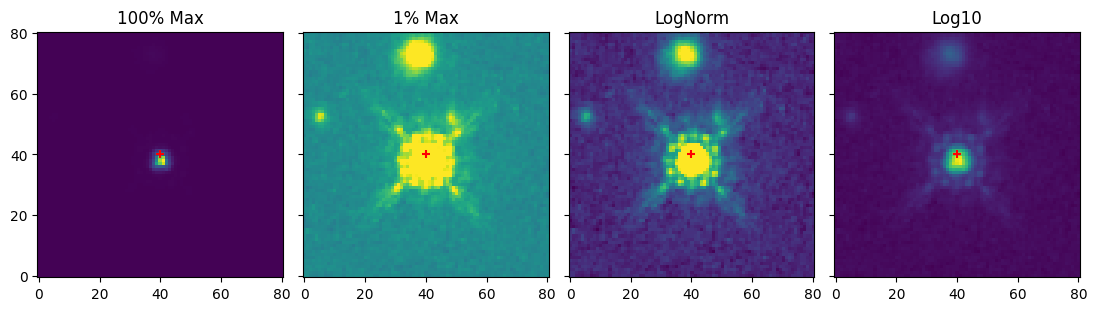

Star ID 34: (x,y) = (1383, 1489)
The read in x, y are: 1382.5559554168744 1488.569369447565
x_shift, y_shift = 0.44404 0.43063
Before shift centroid = 39.9871 39.6327
After shift centroid =  40.0751 39.6661
The subimage peak flux (x,y) = (41), 38)


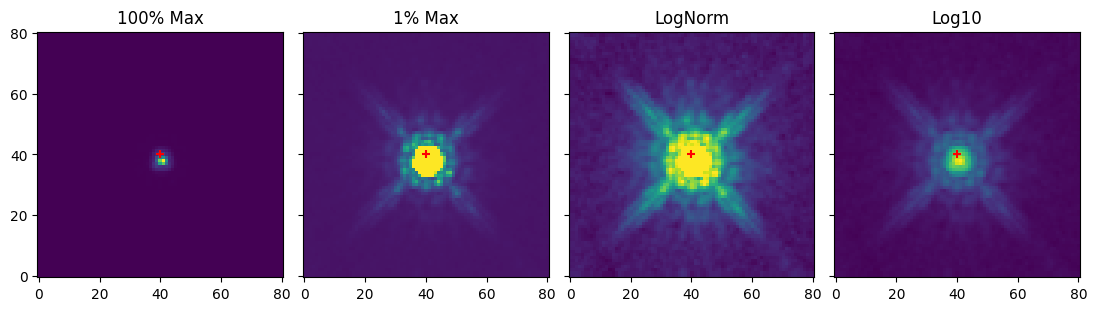

In [10]:
stat_stars = data.detect_stars(detec_fwhm=3,threshold=2.5,verbose=True,make_plots=True,n_keep=5,binary_dilation_iteration=20,use_gaia=True,gaia_gmag_limit=32,gaia_radius=None,)

In [53]:
cwd = os.getcwd()
base_path, _ = os.path.split(cwd)
print(base_path)

lens_name = os.path.basename(base_path)
print(lens_name)

system_name = lens_name
filter_name = 'F814W'

# options for cutout
numPix = 120

system = StrongLensSystem(system_name)

#path_data  = "../../../HST/hst_15320_13_wfc3_uvis_f814w_idgc13/hst_15320_13_wfc3_uvis_f814w_idgc13_drc.fits"
#local_wht_filename =  None#'../reduced_data/2M1134-2103_F160W_drz_wht.fits'
# import the data
# local_filename = os.path.join(base_path, 'reduced_data', image_filename)
# local_wht_filename = os.path.join(base_path, 'reduced_data', wht_filename)

#get info for RA and DEC from file header
header = getheader(path_data)
deltara = 0.0
deltadec = 0.0004
system.add_info_attribute('ra', header['ra_targ'] + deltara)
system.add_info_attribute('dec', header['dec_targ'] + deltadec)

# add image data instance (see astroObjectAnalyser)
system.add_image_data_init(filter_name, local_filename=path_data, local_psf_filename=None, 
                           local_wht_filename=path_wht,
                           ra=system.ra, dec=system.dec, ra_cutout_cent=system.ra, dec_cutout_cent=system.dec,
                           cutout_scale=numPix, data_type='HST_new')

print(system.ra, system.dec)

/Users/felavila/Work/DataStarred/thomas_hst_quad_data/PSJ0147+4630
PSJ0147+4630
26.79229166667 46.51167222222


the center of the image is at pixel coordinates 753.050349, 1079.621688.


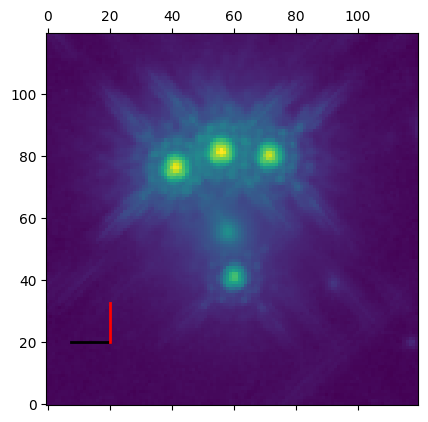

In [55]:
data_cutout = system.get_cutout_image(filter_name, numPix, force=True)  # if force=True, a new cutout with the new options will be made

#%matplotlib notebook

#plot origial data
plt.matshow(np.log10(data_cutout), origin='lower')
plt.autoscale(False)

#plot 1" RA and DEC ruler on image
start_pix = 20      #starting point for ruler
ra0, dec0 = system.pix2coord(filter_name, start_pix, start_pix)
end_pix_ra, end_pix_dec = system.coord2pix(filter_name, ra0 + 1, dec0 + 1)
plt.plot([start_pix,end_pix_ra],[start_pix,start_pix], linewidth=2, color='k')
plt.plot([start_pix,start_pix],[start_pix,end_pix_dec], linewidth=2, color='r')
#plt.scatter(0,0)
plt.show()

In [56]:
deltaPix, _ = system.get_pixel_scale(filter_name) 
deltaPix *= 3600  # convert into arcsec
#print(deltaPix)

# get mean and sigma_bkd of image (computed by SourceExtractor)
mean, sigma_b = system.get_background(filter_name)

ccd gain = 2.5
No filter file found, using default filter
No NNW file found, using default NNW config
sextractor command: sex ../reduced_data/PSJ0147+4630_F160W_drz_sci.fits -c .pysex.sex -GAIN 5492.330935 -CATALOG_NAME .pysex.cat -PARAMETERS_NAME .pysex.param -FILTER_NAME .pysex.conv -STARNNW_NAME .pysex.nnw



> WARNING: This executable has been compiled using a version of the ATLAS library without support for multithreading. Performance will be degraded.

> 
----- SExtractor 2.28.2 started on 2026-06-23 at 19:27:22 with 18 threads

> Setting catalog parameters
> Reading detection filter
> Initializing Neural Network
> Reading Neural Network Weights
> Initializing catalog
> Looking for PSJ0147+4630_F160W_drz_sci.fits
----- Measuring from: PSJ0147+4630_F160W_drz_sci.fits [0/2]
      "Unnamed" / no ext. header / 1685x1908 / 32 bits (floats)
Detection+Measurement image: > Setting up background maps
> Setting up background map at line:   64
> Setting up background map at line:  128
> Setting up background map at line:  192
> Setting up background map at line:  256
> Setting up background map at line:  320
> Setting up background map at line:  384
> Setting up background map at line:  448
> Setting up background map at line:  512
> Setting up background map at line:  576
> Setting up background 

Mean:  0.1821765452623 , Sigma_bckgd:  0.008555728942156
CCD Gain:  2.5
the center of the image is at pixel coordinates 753.050349, 1079.621688.
separate exposure map loaded


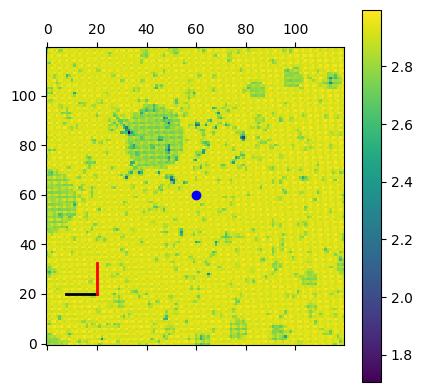

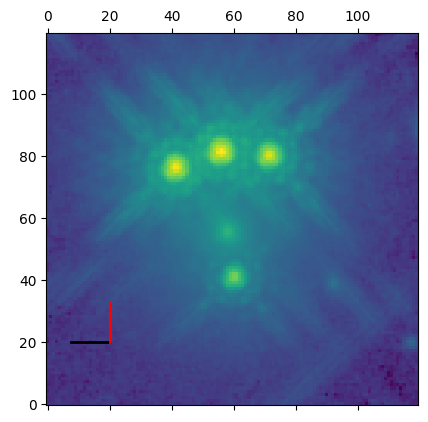

In [57]:
ccd_gain = system.get_CCD_gain(filter_name)
print('Mean: ', mean, ', Sigma_bckgd: ', sigma_b)
print('CCD Gain: ', ccd_gain)

# we subtract the mean background estimate from the cutout image
data_reduced = (data_cutout - mean)#*mask_off

# get exposure time
exp_time = system.get_exposure_time(filter_name)

# here we set the coordinate grid (rectangular)
ra_at_xy_0, dec_at_xy_0 = system.coord_at_pixel_0(filter_name)
#Don't think the following two variables are needed (comment out for now)
#x_at_radec_0, y_at_radec_0 = system.pixel_at_angle_0(filter_name) 
#also not needed
#Matrix = system.get_transform_matrix_angle2pix(filter_name)
#also not needed
#cos_dec = np.cos(system.dec/360*2*np.pi)
matrix_inv = system.get_transform_matrix_pix2angle(filter_name)


# get weight map (effective exposure time per pixel)
wht_map = system.get_exposure_map(filter_name)
# untis in pixels are originally electrons/s
# we estimate the Poisson noise term in respect to a smaller IID count rate
### DON'T DIVIDE BU CCD GAIN (ALREADY IN ELECTRON COUNT)
# wht_map /= ccd_gain # 2.5 is equivalent to the CCD_gain parameter
# for numerics, replace 0 with small number
wht_map[wht_map <= 0] = 10**(-10)  # just making sure that there are non-negative exposure times

#plot weight map with 1" RA and DEC ruler on image
plt.matshow(np.log10(wht_map), origin='lower')
plt.autoscale(False)
plt.plot([start_pix,end_pix_ra],[start_pix,start_pix], linewidth=2, color='k')
plt.plot([start_pix,start_pix],[start_pix,end_pix_dec], linewidth=2, color='r')
#show center of target
x_0, y_0 = system.pixel_at_angle_0(filter_name)
plt.plot(x_0, y_0, 'ob')
plt.colorbar()
plt.show()

#plot data reduced by mean background estimate 
plt.matshow(np.log10(data_reduced), origin='lower')
plt.plot([start_pix,end_pix_ra],[start_pix,start_pix], linewidth=2, color='k')
plt.plot([start_pix,start_pix],[start_pix,end_pix_dec], linewidth=2, color='r')
plt.show()
noise_map_2_system = np.abs(data_reduced) / wht_map + sigma_b**2

In [58]:
from astropy.table import Table

In [59]:
import numpy as np
from scipy.spatial import cKDTree


def make_object_mask(
    catalog,
    x,
    y,
    x_column="X_IMAGE",
    y_column="Y_IMAGE",
    max_separation_pixels=None,
):
    """
    Create a Boolean mask aligned with the rows of a pandas DataFrame.

    For each input (x, y) coordinate, find the closest catalog object in
    pixel coordinates.

    Parameters
    ----------
    catalog : pandas.DataFrame
        Catalog containing the object pixel coordinates.

    x, y : array-like
        Input pixel coordinates to match against the catalog.

    x_column, y_column : str
        Names of the catalog columns containing the x and y coordinates.

    max_separation_pixels : float or None
        Maximum accepted pixel separation. If None, the nearest catalog
        object is always accepted.

    Returns
    -------
    object_mask : ndarray of bool
        Boolean array aligned with the catalog rows. True marks catalog
        objects matched to at least one input coordinate.
    """

    x = np.atleast_1d(np.asarray(x, dtype=float))
    y = np.atleast_1d(np.asarray(y, dtype=float))

    if x.shape != y.shape:
        raise ValueError("x and y must have the same shape.")

    # Ignore invalid input coordinates
    valid_input = np.isfinite(x) & np.isfinite(y)

    x = x[valid_input]
    y = y[valid_input]

    if len(x) == 0:
        raise ValueError("No valid input x/y coordinates were provided.")

    catalog_x = catalog[x_column].to_numpy(dtype=float)
    catalog_y = catalog[y_column].to_numpy(dtype=float)

    valid_catalog = (
        np.isfinite(catalog_x)
        & np.isfinite(catalog_y)
    )

    valid_indices = np.flatnonzero(valid_catalog)

    if len(valid_indices) == 0:
        raise ValueError(
            "The catalog contains no valid pixel coordinates."
        )

    catalog_positions = np.column_stack(
        (
            catalog_x[valid_catalog],
            catalog_y[valid_catalog],
        )
    )

    input_positions = np.column_stack((x, y))

    # Construct a spatial tree from the catalog coordinates
    tree = cKDTree(catalog_positions)

    # Find the closest catalog object for every input position
    separations, matched_local_indices = tree.query(
        input_positions,
        k=1,
    )

    # Convert local indices in catalog_positions back to DataFrame row positions
    matched_indices = valid_indices[matched_local_indices]

    if max_separation_pixels is not None:
        accepted = separations <= max_separation_pixels

        matched_indices = matched_indices[accepted]
        separations = separations[accepted]

    object_mask = np.zeros(len(catalog), dtype=bool)
    object_mask[np.unique(matched_indices)] = True

    return object_mask

In [ ]:
from astropy.table import Table
analysis = Analysis()
cat = system.get_cat(filter_name)
kwargs_cuts = analysis.estimate_star_thresholds(cat)
kwargs_cuts['ClassStarMin'] = 0.1
kwargs_cuts['EllipticityThresh'] = 0.8
kwargs_cuts['MagMinThresh'] = 15
kwargs_cuts['MagMaxThresh'] = 24
kwargs_cuts['SizeMinThresh'] = 0.5
kwargs_cuts['SizeMaxThresh'] = 4
mask_star = analysis.find_objects(cat, kwargs_cuts)
cat_table = Table(cat.data)
mask_obj = make_object_mask(cat_table.to_pandas(),data.phot_table["x_center"].value,data.phot_table["y_center"].value)
mask = (mask_obj | mask_star) #& [i in  [50,131,306,311,563,813,832,1575] for i in cat_table["NUMBER"].value]

In [154]:
cat_table[mask]

NUMBER,FLAGS,X_IMAGE,Y_IMAGE,FLUX_BEST,FLUXERR_BEST,MAG_BEST,MAGERR_BEST,FLUX_RADIUS,CLASS_STAR,A_IMAGE,B_IMAGE,THETA_IMAGE,ELLIPTICITY,X_WORLD,Y_WORLD
int32,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64
50,2,692.4025,133.01633,297.02393,0.29023847,25.44662,0.0010611905,1.8506421,0.97106826,3.4107537,3.145028,76.27035,0.07790816,26.794280383760896,46.49061425831525
131,3,31.240221,84.39162,5036.409,0.9619762,22.373297,0.00020743074,1.1248921,0.99984044,1.8714862,1.0560104,78.182686,0.435737,26.815620547362872,46.489530816215385
306,0,696.17755,295.39505,1153.5541,0.50182414,23.973505,0.00047243648,1.9211905,0.97993267,3.894577,3.818223,47.018673,0.01960522,26.794158850745603,46.494222679564416
311,0,217.5744,276.42947,383.22107,0.3190023,25.169975,0.0009040121,1.8512633,0.97368795,3.408309,3.3185444,66.44531,0.026336968,26.809607846956247,46.493799540785794
563,3,920.27075,573.53046,239.49461,0.3469025,25.680359,0.0015730462,2.2444246,0.97148144,4.0634923,3.322806,41.633503,0.18227828,26.786924916173543,46.50040353779157
813,2,1385.0996,1732.01,6179.2847,1.0890597,22.151253,0.00019140061,1.853841,0.971534,4.949641,4.360002,-71.37971,0.11912769,26.771910407701423,46.52614622306477
832,0,1097.6278,1747.9404,152.45824,0.21900165,26.170721,0.0015600062,1.806777,0.97078514,2.705721,2.6794703,66.246216,0.009701908,26.781195300266827,46.526501271522974
1575,0,1114.5234,1014.0045,376.64938,0.31654376,25.188757,0.00091269636,1.9223593,0.9715906,3.3978395,3.3251588,-73.855736,0.02139026,26.780652214631722,46.51019154440297


In [155]:
# kwargs_cuts['ClassStarMin'] = 0.1
# kwargs_cuts['EllipticityThresh'] = 0.8
# kwargs_cuts['MagMinThresh'] = 18
# kwargs_cuts['MagMaxThresh'] = 24
# kwargs_cuts['SizeMinThresh'] = 0.5
# kwargs_cuts['SizeMaxThresh'] = 4

In [156]:
def get_objects_image(image, cat, mask, cut_fixed=30):
    """
    returns all the cutouts of the locations of the selected objects
    :param image:
    :param cat:
    :param mask:
    :return:
    """
    nx, ny = image.shape
    y_center = np.array(cat.data['X_IMAGE'], dtype=float)
    x_center = np.array(cat.data['Y_IMAGE'], dtype=float)
    obj_number = np.array(cat.data['NUMBER'], dtype=float)
    x_center_mask = x_center[mask]
    y_center_mask = y_center[mask]
    obj_number_mask = obj_number[mask]
    num_objects = len(x_center_mask)
    list = []
    good_obj = []
    numPix = cut_fixed
    for i in range(num_objects):
        xc, yc = x_center_mask[i], y_center_mask[i]
        if (xc-numPix > 0) and (xc+numPix < nx) and (yc-numPix > 0) and (yc+numPix < ny):
            cutout = image[int(xc-numPix):int(xc+numPix+1), int(yc-numPix):int(yc+numPix+1)]
            list.append(cutout)
            good_obj.append(obj_number_mask[i])
    return list,good_obj

separate exposure map loaded


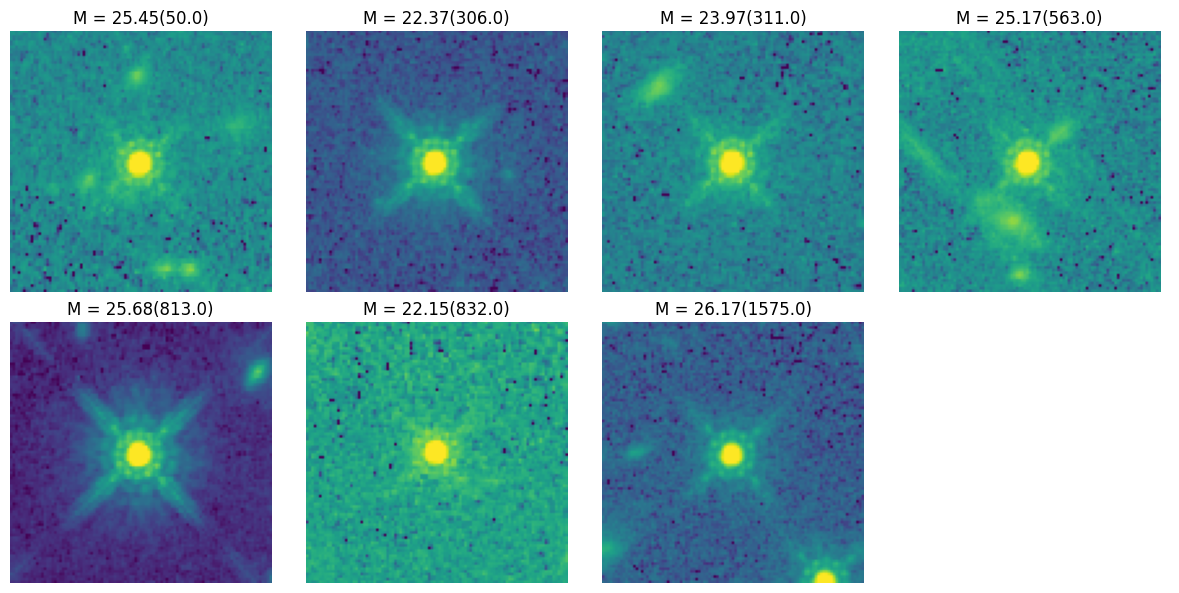

In [157]:
from astropy.visualization import ImageNormalize, LogStretch

#mean_bkd, sigma_bkd = system.get_background(filter_name)
cut_size_star_radius = 50
img_full = system.get_full_image(filter_name) # get the full image
star_imgs,good_obj= get_objects_image(img_full - mean, cat, mask, cut_size_star_radius) # get star cutouts, background subtracted

wht_full = system.get_full_exposure(filter_name) # get the full exposure map
wht_full[wht_full <= 0] = 10**(-10)
star_whts,good_obj = get_objects_image(wht_full, cat, mask, cut_size_star_radius) # get exposure map cutouts for stars

# convert the cutouts into units of e-
# exp_time = system.get_exposure_time(filter)
# print(exp_time)
# star_imgs  = [star_img * exp_time for star_img in star_imgs]

# plot star cutouts
num_stars = len(star_imgs)
ncols = 4 
nrows = (num_stars + ncols - 1) // ncols  # calculate number of rows needed

fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 3 * nrows))
ax = ax.flatten()  # flatten the axes array for easy indexing

for i in range(num_stars):
    # display cutout image
    from astropy.visualization import simple_norm
    #norm = ImageNormalize(np.arccosh(star_imgs[i]), stretch=LogStretch())
    norm = simple_norm(star_imgs[i], stretch="log", percent=99)
    ax[i].imshow(star_imgs[i], norm=norm, cmap='viridis', origin='lower')
    # ax[i].imshow(np.log10(star_whts[i]), cmap='viridis', origin='lower')
    ax[i].set_title('M = {:.2f}' .format(cat_table[mask][i]['MAG_BEST'])+f"({good_obj[i]})") 
    ax[i].axis('off') 

# hide any remaining unused subplots
for j in range(num_stars, nrows * ncols):
    ax[j].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
1575

In [64]:
cat_table[mask]

NUMBER,FLAGS,X_IMAGE,Y_IMAGE,FLUX_BEST,FLUXERR_BEST,MAG_BEST,MAGERR_BEST,FLUX_RADIUS,CLASS_STAR,A_IMAGE,B_IMAGE,THETA_IMAGE,ELLIPTICITY,X_WORLD,Y_WORLD
int32,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64
9,3,397.99622,24.66946,497.02414,0.31047955,24.887655,0.0006783992,2.5422235,0.99983984,2.4074075,1.6918793,18.875856,0.2972194,7.432186829103322,-38.26546665094279
120,2,1622.3423,376.56747,317.35245,0.3909878,25.374744,0.0013379848,4.4457736,0.8461359,6.448341,5.0437593,-47.80898,0.21782058,7.397535952741641,-38.25764636078915
326,0,1817.59,479.60254,179.45001,0.23593448,25.99374,0.0014278342,1.810347,0.9702627,2.8637607,2.7356255,-21.82637,0.044743657,7.392011175973603,-38.25535569759463
363,0,1078.0216,491.49902,35.036533,0.13927656,27.767296,0.0043170466,1.8265808,0.9703792,2.193624,2.0462525,2.7228298,0.067181766,7.412940396763121,-38.25509373377364
478,0,801.66425,817.39264,448.59207,0.54788554,24.99897,0.0013263803,6.788074,0.9157925,9.751033,7.637816,83.85763,0.21671724,7.420760594329801,-38.247851596865864
540,0,1166.4531,925.0505,320.22308,0.4810725,25.364967,0.0016315024,5.9261317,0.92372465,7.8078737,7.572466,40.615253,0.030150056,7.410438599581349,-38.24545916600112
958,2,415.80145,1595.4275,101.93017,0.22732489,26.607841,0.0024219996,2.7422948,0.9809173,3.7078948,3.0460851,-29.493704,0.17848665,7.431675356665735,-38.230560986475126
1113,3,884.1991,1326.5972,767.0297,0.92352116,24.416569,0.0013075686,10.763345,0.44338235,15.471877,12.031178,-65.7132,0.22238404,7.418424786186134,-38.236536013295336
1151,3,921.5514,1373.0497,101.33759,0.274984,26.614172,0.0029469086,2.7337759,0.97518224,3.9262257,3.4895527,62.642002,0.111219525,7.417367999457675,-38.235503751763574


In [65]:
mask.nonzero()[0]

array([   8,  119,  325,  362,  477,  539,  957, 1112, 1150, 1176, 1323])

/var/folders/9p/9nd87mkj1278f_ny5pgsc0zc0000gn/T/ipykernel_58893/872732889.py:19: RuntimeWarning: invalid value encountered in arccosh
  norm = ImageNormalize(np.arccosh(star_imgs[i]), vmin=-0.2, vmax=25, stretch=LogStretch())


IndexError: list index out of range

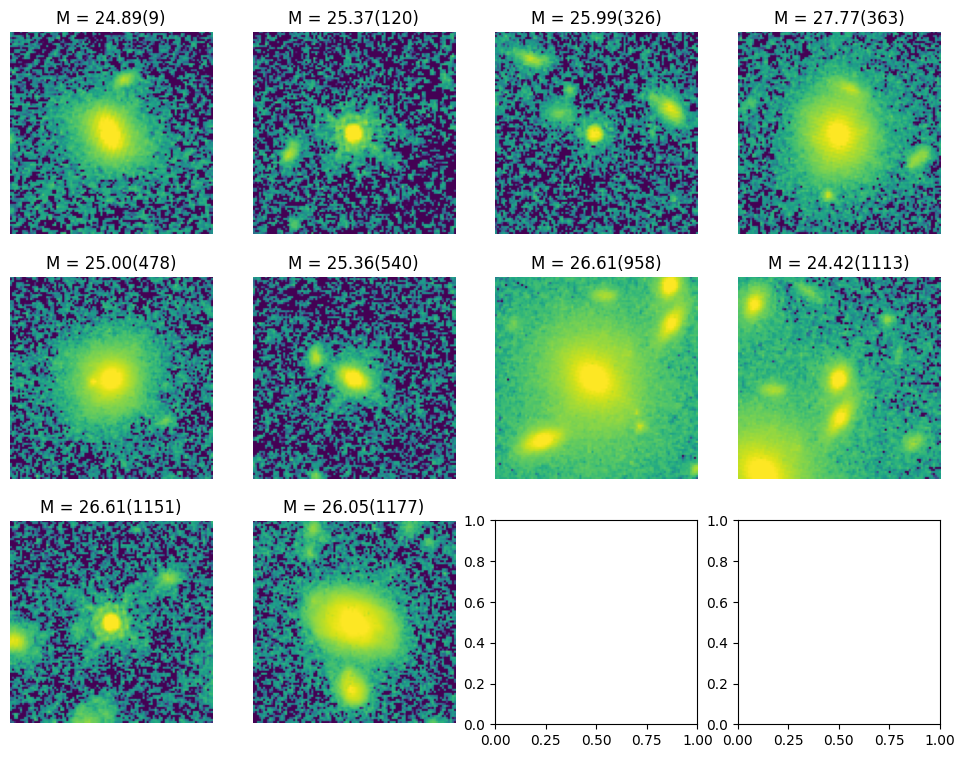

In [66]:
# generate input for STARRED
# make noise map
noise_maps = []
for i, star_img in enumerate(star_imgs):
    nx_im, ny_im = np.shape(star_img)
    noise_map_2 = np.abs(star_img) / star_whts[i] + sigma_b**2
    noise_maps.append(np.sqrt(noise_map_2))

# plot star cutouts
num_stars = len(mask.nonzero()[0])
ncols = 4 
nrows = (num_stars + ncols - 1) // ncols  # calculate number of rows needed

fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 3 * nrows))
ax = ax.flatten()  # flatten the axes array for easy indexing

for i,nstar in zip(np.arange(num_stars),mask.nonzero()[0]):
    # display cutout image
    norm = ImageNormalize(np.arccosh(star_imgs[i]), vmin=-0.2, vmax=25, stretch=LogStretch())
    ax[i].imshow(star_imgs[i] / noise_maps[i], norm=norm, cmap='viridis', origin='lower')
    # ax[i].imshow(noise_maps[i], cmap='viridis', origin='lower', norm=norm)
    ax[i].set_title('M = {:.2f}' .format(cat_table[mask][i]['MAG_BEST'])+f"({cat_table[mask][i]['NUMBER']})") 
    ax[i].axis('off') 

# hide any remaining unused subplots
for j in range(num_stars, nrows * ncols):
    ax[j].axis('off')

plt.tight_layout()
plt.show()